In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/base_wine_limpa.csv')

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


In [5]:
df['cluster_quality'].unique()

array([0, 1])

In [6]:
df['cluster_quality'].value_counts()

cluster_quality
0    881
1    137
Name: count, dtype: int64

In [9]:
#Removendo a coluna quality para evitar vazemento de dados no modelo (Acho que vale tirar na construção do DF)

df = df.drop(columns='quality')

Ponto importante, téoricamente o nosso DF tem uma diferença grande entre produtos ruins e produtos bons (Colega Carlos mencionou no EDA)

Aqui pode ser um ponto que posso testar com os tipos de balanceamentos durante os testes dos modelos.

Separação dos dados

In [12]:
#Separando X e Y

x = df.drop(columns='cluster_quality')
y = df['cluster_quality']

In [14]:
#Definido a seed do modelo

SEED = 73264

In [15]:
#Separação entre traino e teste com a lib sklearn

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.3, random_state=SEED)

Antes de gerar os modelos, é preciso explicar como o XGBoost funciona, para contextualizar o código

XGBoost: implementa algoritmos de aprendizado de máquina sob a estrutura do Gradient Boosting.

Como Funciona? Ele cria uma "arvore de precisão", onde cada galho é uma tentativa de previsão, e que o próximo aprende com o ultimo e melhora sucessivamente.

Baseline

In [ ]:
#Baseline manual, onde todos as amostras são Vinhos de Qualidade
print(f'Baseline simples: {len(df.query('`cluster_quality` == True')) / len(df) * 100:.2f}%')

Baseline simples: 13.46%


In [29]:
#Criando um falso modelo para criar valor de Baseline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy='constant', constant=1) #Qual método Utilizar no fim?
baseline.fit(x_train, y_train)

preds = baseline.predict(x_test)

print(f"Baseline com Dummy: {(accuracy_score(y_test, preds))*100:.2f}%")

Baseline com Dummy: 13.46%


Baseline com Dummy apresentou alguns resultados: 
- stratified: 77.14%
- most_frequent: 86.54%
- uniform: 49.79%
- constant: 1 - 13.46% / 0 - 86.54%

O Valor alto em "argumentos constantes" é explicado pela distribuição da qualidade dos vinhos.

DecisionTree

Por que DecisionTree ? 

Como o nosso modelo de XGBoost trabalha com a base em arvore de decisiões, é valido trazer como esse modelo se comporta e se realmente compensa utilizar o XGBoost.

(Aqui eu criei apenas para comparação, mas quando formos estruturar o doc final, irei utilizar o modelo montado pelo colega Carlos)

In [32]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4) 
model.fit(x_train, y_train) 

y_pred = model.predict(x_test) 

print(f'Modelo com acurácia de {(accuracy_score(y_test, y_pred)*100):.2f}%')

Modelo com acurácia de 85.13%


A Acurácia do modelo de decisão já nos retorna um resultado excelente para um modelo de ML.

Aqui já podemos como base se vale a complexidade do XGBoost para esse modelo. Minha hipotese é: Não vale, 85% é uma precisão muito alta já, mas seguiremos com o teste

XGBoost

In [34]:
import xgboost as xgb

In [36]:
model_xgb = xgb.XGBClassifier(objective='binary:logistic') #Parametro para idincar o modelo que é classificação binária
 
model_xgb.fit(x_train, y_train)

y_pred_xgb = model_xgb.predict(x_test)

print(f'Modelo com acurácia de {(accuracy_score(y_test, y_pred_xgb)*100):.2f}%')

Modelo com acurácia de 86.12%


Aqui ta o pulo do gato, inicialmente, a acuracia está praticamente igual a do modelo de decisão. 

Vale entender outras métricas (Matriz De Confusão, Validação Cruzada, Curva ROC a AUC etc.), comparar com o resultado dos colegas, e por na balança se compensa ou não.

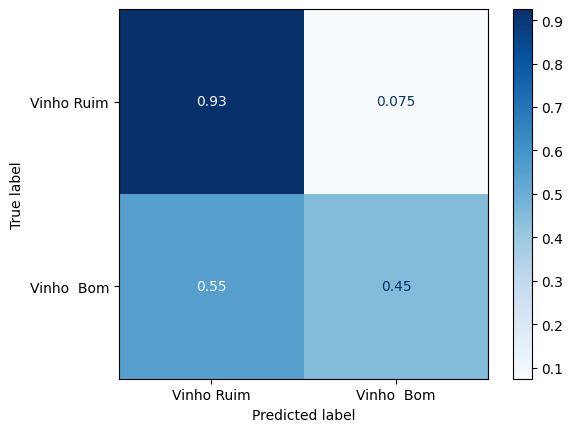

In [42]:
#Matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model_xgb, x_test, y_test, cmap='Blues', normalize='true', display_labels=['Vinho Ruim', 'Vinho  Bom'])

Estranho... 
A Matriz de confusão indicou que em 55% das vezes o modelo colocou que os vinhos bons são ruins.

Levando em consideração que a quantidade de vinhos é muito baixa, ele está com dificuldade de prever quando o vinho bom é bom.

90% de certeza que é a questão do balanceamento dos dados, porque o modelo ve muito vinhos ruins, poucos bons no treino oque pode impedir de aprender a complexidade dos vinhos bons.



Para teste vou gerar uma base com os dados balanceados e criar um modelo novo para comparar o resultado e ver se melhora essa matriz.

Uma informação legal sobre os tipos de balanceamentos: https://sigmoidal.ai/estrategias-de-balanceamento-de-dados-em-machine-learning/

Inicialmente vou usar o Método Class Weight (Nativa do SKlearn), que da um peso maior a classe minoritária, no nosso caso, vinhos bons.

In [ ]:
classes_counts = y_train.value_counts() #Salvando a distribuição das classes da base de treino

peso_positivo = classes_counts[0] / classes_counts[1] #Fazendo a divisão para entender a diferença em x da classe majoritaria sobre minoritaria. 

np.int64(41)

Fonte: https://medium.com/@mate.voros1998/handling-imbalanced-datasets-with-xgboost-optimizing-model-performance-with-smart-parameter-tuning-18568c7783cf

Criando o Modelo com a função de peso

In [48]:

modelo_xgb_balanced = xgb.XGBClassifier(objective='binary:logistic', scale_pos_weight=peso_positivo)

modelo_xgb_balanced.fit(x_train, y_train)

y_pred_xgb_balanced= modelo_xgb_balanced.predict(x_test)

print(f'Modelo com acurácia de {(accuracy_score(y_test, y_pred_xgb_balanced)*100):.2f}%')

Modelo com acurácia de 84.15%


Acurácia diminui no total, vamos ver a matriz de confusão.

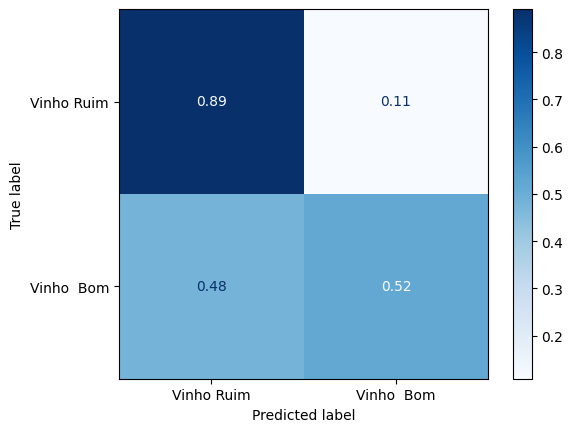

In [49]:
#Matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(modelo_xgb_balanced, x_test, y_test, cmap='Blues', normalize='true', display_labels=['Vinho Ruim', 'Vinho  Bom'])

Melhoramos a quantidade de acerto de vinhos bons, mas muito pouco...e perdos precisão nos vinhos ruins. 

Vou aplicar outros balanceamentos com a lib de balanceamento para teste.

In [50]:
#instalar imbalanced-lean